# Ridge Regression: Bitcoin Daily Returns Prediction

Predicting Bitcoin daily returns using Ridge regression with momentum and volatility features.

## Load and prepare data

Load historical price data and sort by date.

In [9]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12

DATA_PATH = "../data/raw/bitcoin_price_training_data.csv"
df = pd.read_csv(DATA_PATH)

df["Date"] = pd.to_datetime(df["Date"], format="%b %d, %Y", errors="coerce")
if df["Date"].isna().all():
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df = df.sort_values("Date", ascending=True).reset_index(drop=True)
df.head()

,Date,Open,High,Low,Close,Volume,Market Cap
0,2013-04-28,135.30,135.98,132.10,134.21,-,"1,500,520,000"
1,2013-04-29,134.44,147.49,134.00,144.54,-,"1,491,160,000"
2,2013-04-30,144.00,146.93,134.05,139.00,-,"1,597,780,000"
3,2013-05-01,139.00,139.89,107.72,116.99,-,"1,542,820,000"
4,2013-05-02,116.38,125.60,92.28,105.21,-,"1,292,190,000"


## Clean numeric columns

Convert Volume and Market Cap from strings to numeric values.

In [10]:
def clean_currency_series(s: pd.Series) -> pd.Series:
    """Remove commas, treat '-' as zero, coerce to float."""
    cleaned = (
        s.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("-", "0", regex=False)
        .str.strip()
    )
    return pd.to_numeric(cleaned, errors="coerce")


for col in ["Volume", "Market Cap"]:
    if col in df.columns:
        df[col] = clean_currency_series(df[col])

df.head()

,Date,Open,High,Low,Close,Volume,Market Cap
0,2013-04-28,135.30,135.98,132.10,134.21,0,1500520000
1,2013-04-29,134.44,147.49,134.00,144.54,0,1491160000
2,2013-04-30,144.00,146.93,134.05,139.00,0,1597780000
3,2013-05-01,139.00,139.89,107.72,116.99,0,1542820000
4,2013-05-02,116.38,125.60,92.28,105.21,0,1292190000


## Feature engineering

Create features: daily returns, 3-day returns, deviation from 7-day MA, and 7-day volatility.

In [11]:
df["Return_1d"] = df["Close"].pct_change()
df["Return_3d"] = df["Close"].pct_change(3)

sma_7 = df["Close"].rolling(window=7, min_periods=7).mean()
df["SMA_7_diff"] = (df["Close"] - sma_7) / sma_7

df["Volatility_7"] = df["Return_1d"].rolling(window=7, min_periods=7).std()

df["Next_Return"] = df["Return_1d"].shift(-1)
df["Next_Close"] = df["Close"].shift(-1)

df = df.dropna(subset=["Return_1d", "Return_3d", "SMA_7_diff", "Volatility_7", "Next_Return", "Next_Close"]).reset_index(drop=True)

df[["Date", "Close", "Return_1d", "Return_3d", "SMA_7_diff", "Volatility_7", "Next_Return"]].tail()

,Date,Close,Return_1d,Return_3d,SMA_7_diff,Volatility_7,Next_Return
1543,2017-07-26,2529.45,-0.018254,-0.073597,-0.062505,0.104637,0.056269
1544,2017-07-27,2671.78,0.056269,-0.030158,-0.002048,0.048220,0.051363
1545,2017-07-28,2809.01,0.051363,0.090251,0.041360,0.047562,-0.029391
1546,2017-07-29,2726.45,-0.029391,0.077883,0.015252,0.044713,0.011271
1547,2017-07-30,2757.18,0.011271,0.031964,0.025235,0.043526,0.042855


## Train/test split

80% for training, 20% for testing. No random shuffling to maintain time-series ordering.

In [12]:
feature_cols = ["Return_1d", "Return_3d", "SMA_7_diff", "Volatility_7"]
target_col = "Next_Return"

X = df[feature_cols]
y = df[target_col]

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

test_df = df.iloc[split_idx:].copy()

len(X_train), len(X_test), split_idx

(1238, 310, 1238)

## Model training

Ridge regression with alpha=100.0. Prevents overfitting by adding L2 penalty to coefficients.

In [13]:
model = Ridge(alpha=100.0, random_state=42)
model.fit(X_train, y_train)

predicted_returns = model.predict(X_test)
predicted_returns[:5]

array([0.00222806, 0.00222918, 0.00223343, 0.00223869, 0.00223094])

## Evaluation

- RMSE: error in dollar terms
- Directional accuracy: % of correct up/down predictions
- Sharpe ratio: risk-adjusted returns of a simple sign-based trading strategy

In [14]:
actual_next_return = test_df["Next_Return"].to_numpy()
pred = np.asarray(predicted_returns)

predicted_next_close = test_df["Close"].to_numpy() * (1.0 + pred)
actual_next_close = test_df["Next_Close"].to_numpy()

rmse_price = np.sqrt(mean_squared_error(actual_next_close, predicted_next_close))

directional_accuracy = np.mean(np.sign(pred) == np.sign(actual_next_return))

strategy_return = np.sign(pred) * actual_next_return
sr_mean = np.mean(strategy_return)
sr_std = np.std(strategy_return, ddof=1)
annualized_sharpe = np.sqrt(365) * (sr_mean / sr_std) if sr_std > 0 else np.nan

print("=" * 52)
print("OUT-OF-SAMPLE FINANCIAL METRICS (TEST WINDOW)")
print("=" * 52)
print(f"RMSE (reconstructed next close vs. actual): {rmse_price:,.2f}")
print(f"Directional accuracy:                     {directional_accuracy:.2%}")
print(f"Annualized Sharpe (sign strategy, rf=0): {annualized_sharpe:.4f}")
print("=" * 52)

OUT-OF-SAMPLE FINANCIAL METRICS (TEST WINDOW)
RMSE (reconstructed next close vs. actual): 68.91
Directional accuracy:                     63.23%
Annualized Sharpe (sign strategy, rf=0): 2.9358


## Results and comparison

Compare strategy performance vs. buy-and-hold approach.

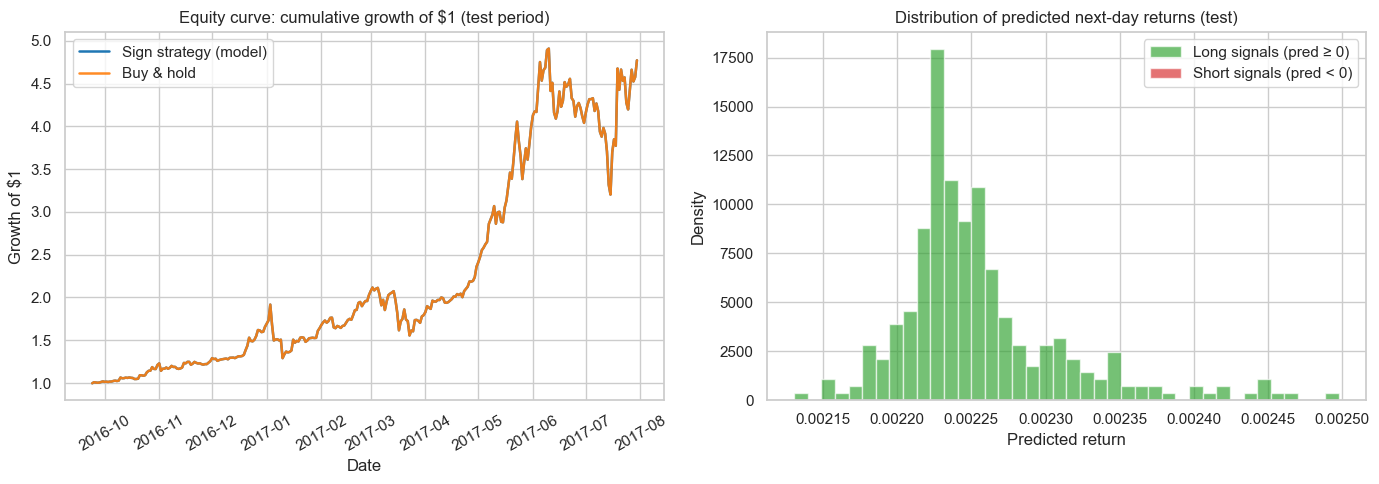

In [15]:
strategy_return = np.sign(predicted_returns) * test_df["Next_Return"].to_numpy()
equity_strategy = (1.0 + pd.Series(strategy_return, index=test_df.index)).cumprod()
equity_buy_hold = (1.0 + test_df["Next_Return"]).cumprod()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax0 = axes[0]
ax0.plot(test_df["Date"], equity_strategy, label="Sign strategy (model)", color="#1f77b4", linewidth=1.8)
ax0.plot(test_df["Date"], equity_buy_hold, label="Buy & hold", color="#ff7f0e", linewidth=1.8, alpha=0.9)
ax0.set_title("Equity curve: cumulative growth of $1 (test period)")
ax0.set_xlabel("Date")
ax0.set_ylabel("Growth of $1")
ax0.legend(loc="best")
ax0.tick_params(axis="x", rotation=30)

ax1 = axes[1]
pos_mask = predicted_returns >= 0
ax1.hist(
    predicted_returns[pos_mask],
    bins=40,
    alpha=0.65,
    color="#2ca02c",
    label="Long signals (pred ≥ 0)",
    density=True,
)
ax1.hist(
    predicted_returns[~pos_mask],
    bins=40,
    alpha=0.65,
    color="#d62728",
    label="Short signals (pred < 0)",
    density=True,
)
ax1.set_title("Distribution of predicted next-day returns (test)")
ax1.set_xlabel("Predicted return")
ax1.set_ylabel("Density")
ax1.legend(loc="best")

plt.tight_layout()
plt.show()